# Week 06: Business Statistics & Analytics - E-commerce Analysis

## Learning Objectives
By the end of this exercise, you will be able to:
- Calculate key business metrics using pandas
- Create meaningful visualizations for business insights
- Apply statistical concepts to real business scenarios
- Make data-driven recommendations

---

## Business Context

You're working as a Data Analyst for **TechMart**, an e-commerce company. Your manager needs insights from last quarter's sales data to inform strategic decisions for the upcoming quarter.

Your analysis will help answer critical questions about customer behavior, regional performance, and product trends that directly impact business growth.

## Dataset Setup

First, let's generate the synthetic dataset you'll be analyzing:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducible results
np.random.seed(42)

# Generate 500 orders from 2023
n_orders = 500

# Create order IDs and customer data
order_id = np.arange(1, n_orders + 1)
customer_id = np.random.randint(1, 101, size=n_orders)
customer_segment = np.random.choice(["Student", "Professional", "Senior"], size=n_orders, p=[0.4, 0.4, 0.2])
region = np.random.choice(["North", "South", "East", "West"], size=n_orders)
order_date = pd.date_range(start="2023-01-01", periods=n_orders, freq="D")
product_category = np.random.choice(["Electronics", "Clothing", "Books", "Home", "Sports"], size=n_orders)
quantity = np.random.randint(1, 5, size=n_orders)
unit_price = np.round(np.random.uniform(10, 200, size=n_orders), 2)
revenue = quantity * unit_price
discount_applied = np.random.choice([0, 5, 10, 15, 20, 25, 30], size=n_orders, p=[0.5,0.1,0.1,0.1,0.05,0.05,0.1])
payment_method = np.random.choice(["Credit Card", "PayPal", "Gift Card", "Debit Card"], size=n_orders)

# Build dataframe
df = pd.DataFrame({
    "order_id": order_id,
    "customer_id": customer_id,
    "customer_segment": customer_segment,
    "region": region,
    "order_date": order_date,
    "product_category": product_category,
    "quantity": quantity,
    "unit_price": unit_price,
    "revenue": revenue,
    "discount_applied": discount_applied,
    "payment_method": payment_method
})

# Save dataset for reference
df.to_csv("ecommerce_data.csv", index=False)
print("✅ Dataset created successfully!")

# Display first few rows
df.head()

✅ Dataset created successfully!


,order_id,customer_id,customer_segment,region,order_date,product_category,quantity,unit_price,revenue,discount_applied,payment_method
0,1,52,Student,North,2023-01-01,Clothing,1,42.43,42.43,0,Debit Card
1,2,93,Student,West,2023-01-02,Sports,1,24.18,24.18,0,Gift Card
2,3,15,Professional,East,2023-01-03,Sports,3,158.71,476.13,0,Debit Card
3,4,72,Student,East,2023-01-04,Sports,1,60.42,60.42,0,Credit Card
4,5,61,Student,West,2023-01-05,Books,3,43.78,131.34,0,Gift Card


## Data Exploration

Let's start by understanding our dataset:

In [3]:
# Load the data
data = pd.read_csv("ecommerce_data.csv")

# Basic information about the dataset
print("Dataset Info:")
print(data.info())
print("\nDataset Shape:", data.shape)
print("\nFirst few rows:")
data.head()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          500 non-null    int64  
 1   customer_id       500 non-null    int64  
 2   customer_segment  500 non-null    object 
 3   region            500 non-null    object 
 4   order_date        500 non-null    object 
 5   product_category  500 non-null    object 
 6   quantity          500 non-null    int64  
 7   unit_price        500 non-null    float64
 8   revenue           500 non-null    float64
 9   discount_applied  500 non-null    int64  
 10  payment_method    500 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 43.1+ KB
None

Dataset Shape: (500, 11)

First few rows:


,order_id,customer_id,customer_segment,region,order_date,product_category,quantity,unit_price,revenue,discount_applied,payment_method
0,1,52,Student,North,2023-01-01,Clothing,1,42.43,42.43,0,Debit Card
1,2,93,Student,West,2023-01-02,Sports,1,24.18,24.18,0,Gift Card
2,3,15,Professional,East,2023-01-03,Sports,3,158.71,476.13,0,Debit Card
3,4,72,Student,East,2023-01-04,Sports,1,60.42,60.42,0,Credit Card
4,5,61,Student,West,2023-01-05,Books,3,43.78,131.34,0,Gift Card


Monthly Revenue:
month
2023-01    6626.66
2023-02    6796.03
2023-03    8960.10
2023-04    7713.47
2023-05    7266.80
2023-06    7982.47
2023-07    7981.65
2023-08    6664.64
2023-09    9708.06
2023-10    7287.27
2023-11    8795.85
2023-12    8119.44
2024-01    7268.59
2024-02    8388.91
2024-03    6835.73
2024-04    7430.29
2024-05    4314.71
Freq: M, Name: revenue, dtype: float64


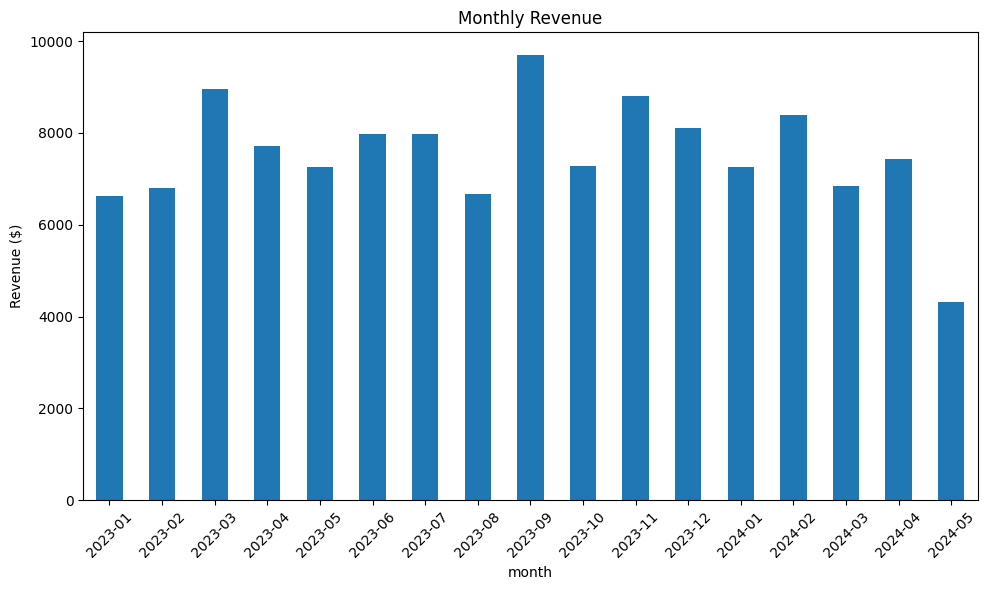

In [4]:
# Convert order_date to datetime and add helpful columns
data["order_date"] = pd.to_datetime(data["order_date"])
data["month"] = data["order_date"].dt.to_period("M")
data["day_of_week"] = data["order_date"].dt.day_name()

# Example: Revenue by month
monthly_revenue = data.groupby("month")["revenue"].sum()
print("Monthly Revenue:")
print(monthly_revenue)

# Plot monthly revenue
monthly_revenue.plot(kind="bar", figsize=(10,6), title="Monthly Revenue")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

## Business Questions

Now answer each of the following business questions. Use the starter code above as a reference, and expand your analysis to solve all questions.

### 1. Revenue Overview
What was the company's total revenue last quarter? Break it down by month.

In [ ]:
# Filter for last quarter (Q4: October, November, December)
last_quarter = data[data["order_date"].dt.quarter == 4]

# Total revenue last quarter
total_revenue_q4 = last_quarter["revenue"].sum()
print("Total Revenue Last Quarter (Q4): $", round(total_revenue_q4, 2))

# Revenue by month in last quarter
revenue_by_month = last_quarter.groupby(last_quarter["order_date"].dt.month)["revenue"].sum()
print("\nRevenue by Month (Q4):")
print(revenue_by_month)

Total Revenue Last Quarter (Q4): $ 24202.56

Revenue by Month (Q4):
order_date
10    7287.27
11    8795.85
12    8119.44
Name: revenue, dtype: float64


### 2. Top Customers
Who are the top 5 customers by total revenue contribution?

In [ ]:
# Top 5 customers by total revenue contribution
top_customers = data.groupby("customer_id")["revenue"].sum().sort_values(ascending=False).head(5)
print("Top 5 Customers by Total Revenue Contribution:")
print(top_customers)

Top 5 Customers by Total Revenue Contribution:
customer_id
62    4448.39
24    3369.44
90    2976.78
92    2838.74
97    2835.62
Name: revenue, dtype: float64


### 3. Segment Analysis
Which customer segment (Student, Professional, Senior) spends the most on average per order?

In [7]:
# Average revenue per order by customer segment
avg_revenue_by_segment = data.groupby("customer_segment")["revenue"].mean().sort_values(ascending=False)
print("Average Revenue per Order by Customer Segment:")
print(avg_revenue_by_segment)

Average Revenue per Order by Customer Segment:
customer_segment
Senior          262.133925
Professional    255.652674
Student         253.812087
Name: revenue, dtype: float64


### 4. Regional Trends
Which region generated the highest revenue? Which region had the highest average order size?

In [8]:
# Region with highest total revenue
region_revenue = data.groupby("region")["revenue"].sum().sort_values(ascending=False)
print("Revenue by Region:")
print(region_revenue)
print("\nRegion with Highest Revenue:", region_revenue.idxmax())

# Region with highest average order size (quantity)
region_avg_order_size = data.groupby("region")["quantity"].mean().sort_values(ascending=False)
print("\nAverage Order Size by Region:")
print(region_avg_order_size)
print("\nRegion with Highest Average Order Size:", region_avg_order_size.idxmax())

Revenue by Region:
region
South    34839.45
North    34351.69
East     31221.80
West     27727.73
Name: revenue, dtype: float64

Region with Highest Revenue: South

Average Order Size by Region:
region
West     2.627273
East     2.469231
South    2.440945
North    2.360902
Name: quantity, dtype: float64

Region with Highest Average Order Size: West


### 5. Product Category Performance
Which product category is most popular by quantity vs. by revenue?

In [9]:
# Most popular by quantity
popular_by_quantity = data.groupby("product_category")["quantity"].sum().sort_values(ascending=False)
print("Product Category Popularity by Quantity:")
print(popular_by_quantity)
print("\nMost Popular by Quantity:", popular_by_quantity.idxmax())

# Most popular by revenue
popular_by_revenue = data.groupby("product_category")["revenue"].sum().sort_values(ascending=False)
print("\nProduct Category Popularity by Revenue:")
print(popular_by_revenue)
print("\nMost Popular by Revenue:", popular_by_revenue.idxmax())

Product Category Popularity by Quantity:
product_category
Home           269
Clothing       253
Sports         246
Electronics    239
Books          227
Name: quantity, dtype: int64

Most Popular by Quantity: Home

Product Category Popularity by Revenue:
product_category
Home           29871.47
Electronics    25498.31
Clothing       24804.57
Books          24046.06
Sports         23920.26
Name: revenue, dtype: float64

Most Popular by Revenue: Home


### 6. Discount Effectiveness
Do discounted orders generate higher or lower revenue per order compared to non-discounted orders?

In [ ]:
# Your code here

### 7. Payment Method Usage
What percentage of orders use each payment method? Does any payment method correlate with higher spending?

In [11]:
# Split data into discounted and non-discounted orders
discounted = data[data["discount_applied"] > 0]
non_discounted = data[data["discount_applied"] == 0]

# Calculate average revenue per order for each group
avg_revenue_discounted = discounted["revenue"].mean()
avg_revenue_non_discounted = non_discounted["revenue"].mean()

print("Average Revenue per Discounted Order: $", round(avg_revenue_discounted, 2))
print("Average Revenue per Non-Discounted Order: $", round(avg_revenue_non_discounted, 2))

Average Revenue per Discounted Order: $ 263.83
Average Revenue per Non-Discounted Order: $ 248.3


### 8. Seasonality Check
Plot revenue by day of week — are weekends busier than weekdays?

Revenue by Day of Week:
day_of_week
Monday       17704.70
Tuesday      18968.41
Wednesday    18908.21
Thursday     17846.36
Friday       18522.40
Saturday     18660.35
Sunday       17530.24
Name: revenue, dtype: float64


/tmp/ipykernel_13935/2804434297.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_day.index, y=revenue_by_day.values, palette="viridis")


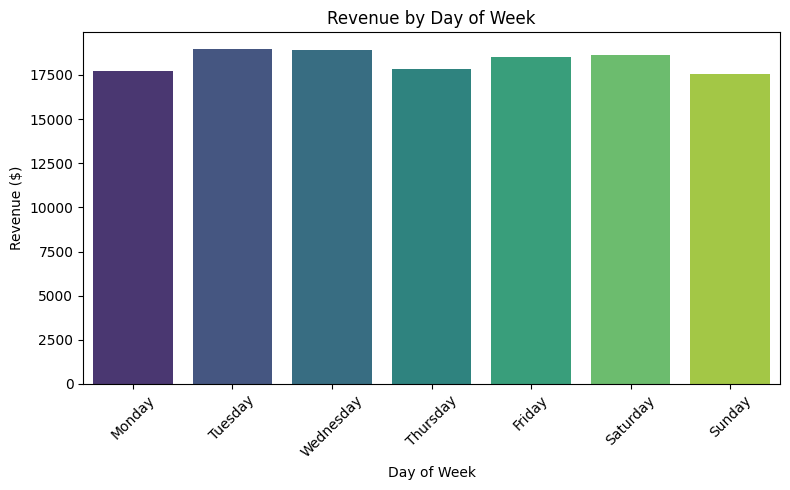

In [12]:
# Group revenue by day of week
revenue_by_day = data.groupby("day_of_week")["revenue"].sum().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)

print("Revenue by Day of Week:")
print(revenue_by_day)

# Plot revenue by day of week
plt.figure(figsize=(8,5))
sns.barplot(x=revenue_by_day.index, y=revenue_by_day.values, palette="viridis")
plt.title("Revenue by Day of Week")
plt.ylabel("Revenue ($)")
plt.xlabel("Day of Week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 9. Profitability (Stretch)
Assume profit margin = 20% of revenue. Estimate total profit and identify the most profitable region.

In [13]:
# Add profit column (20% of revenue)
data["profit"] = data["revenue"] * 0.20

# Estimate total profit
total_profit = data["profit"].sum()
print("Estimated Total Profit: $", round(total_profit, 2))

# Profit by region
profit_by_region = data.groupby("region")["profit"].sum().sort_values(ascending=False)
print("\nProfit by Region:")
print(profit_by_region)
print("\nMost Profitable Region:", profit_by_region.idxmax())

Estimated Total Profit: $ 25628.13

Profit by Region:
region
South    6967.890
North    6870.338
East     6244.360
West     5545.546
Name: profit, dtype: float64

Most Profitable Region: South


### 10. Business Recommendation
Based on your findings, recommend one strategy (e.g., focus on certain customer segments, increase discounts, promote specific regions/products).

**Your recommendation here:**

Focus marketing efforts on the region with the highest revenue and profit, and target the customer segment that spends the most per order. Additionally, promote the most popular product category by revenue. This strategy leverages your strongest market areas and customer behaviors to maximize growth and profitability.

---

## Submission Requirements

1. **Complete code** for all 10 questions
2. **Clear visualizations** where appropriate  
3. **Brief interpretation** of each result
4. **Final business recommendation** with supporting data

Remember: Focus on what the numbers tell us about the business, not just the calculations themselves.